# Deconvolution

In [1]:
# mv this notebook in src folder
# or
# set sys path to src folder
import os, sys
path_to_scr_folder=os.path.join(os.path.dirname(os.path.abspath('')), 'src')
sys.path.append(path_to_scr_folder)


In [2]:
import plot
from read_chroma import read_only_chroma, read_chromato_and_chromato_cube
import matplotlib.pyplot as plt
from identification import compute_matches_identification, cohort_identification_alignment_input_format_txt, cohort_identification_to_csv, sample_identification
from matching import matching_nist_lib_from_chromato_cube
import projection
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

import mass_spec
from sklearn.cluster import DBSCAN
from scipy.signal import savgol_filter
from skimage.restoration import estimate_sigma
import dbscan_peak
from whittaker_eilers import WhittakerSmoother
import deconvolution


In [ ]:
filename='D:/cdf centroid/A-F-028-817822-droite-ReCIVA.cdf'
chromato, time_rn=read_only_chroma(filename, mod_time=1.7)

Loaded 103007595 mass values
Non-finite mass values: 0
[]
[]


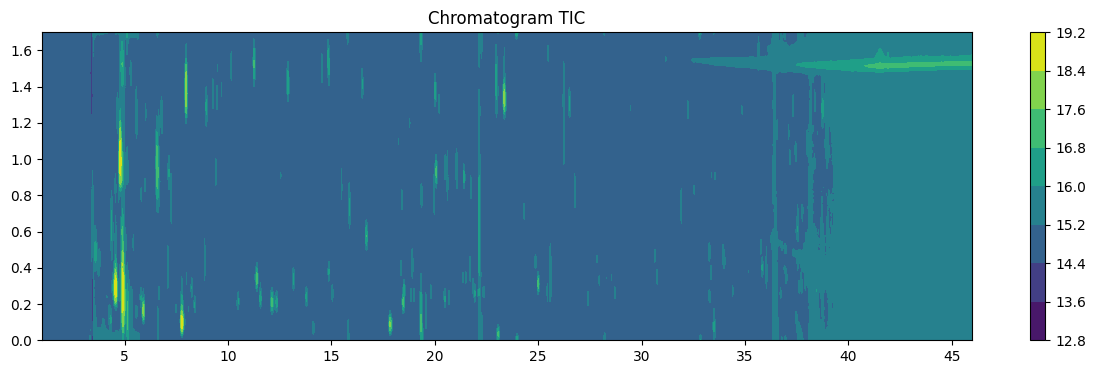

chromato read 6.582690954208374 s
--- 79.47349214553833 seconds --- to compute full spectra centroid
full spectra computed 81.67468690872192 s


In [3]:
filename="/app/GCxGC/GCxGC/APPROCHS/001_2382_FA_J14.cdf"
filename="D:/VOLATIL-CF_03/751316_QCd20new.cdf"
filename="D:/GCxGC/APPROCHS/001_2382_FA_J14.cdf"
filename='D:/cdf centroid/B-A-009-751353-gauche-ReCIVA.cdf'
#filename='D:/cdf centroid/B-K-031-751355-Tedlar.cdf'
filename="D:/DC volatil cf 8/2025-04-16_751318_QCnew23EI.cdf"
filename = "D:/GCxGC/gamme/751343_gamme_1ppm.cdf"
filename='D:/cdf centroid/A-F-028-817822-droite-ReCIVA.cdf'

chromato, time_rn, chromato_cube, sigma, mass_range=read_chromato_and_chromato_cube(filename, mod_time=1.7, pre_process=False)

In [4]:
chromato_cube = chromato_cube[:400,:,:]

In [5]:
print("baseline correction")
from baseline_correction import baseline_correct_mp
#baseline_cube = np.array([baseline_correct(chromato_cube[m,:,:]) for m in range(chromato_cube.shape[0])]) # multiprocess 
baseline_cube=baseline_correct_mp(chromato_cube)

baseline correction


c:\Users\camil\OneDrive\Documents\02-Code source\Adeline\Python-2DGC-Alignment\src\plot.py:608: RuntimeWarning: divide by zero encountered in log
  chromato = np.log(chromato)


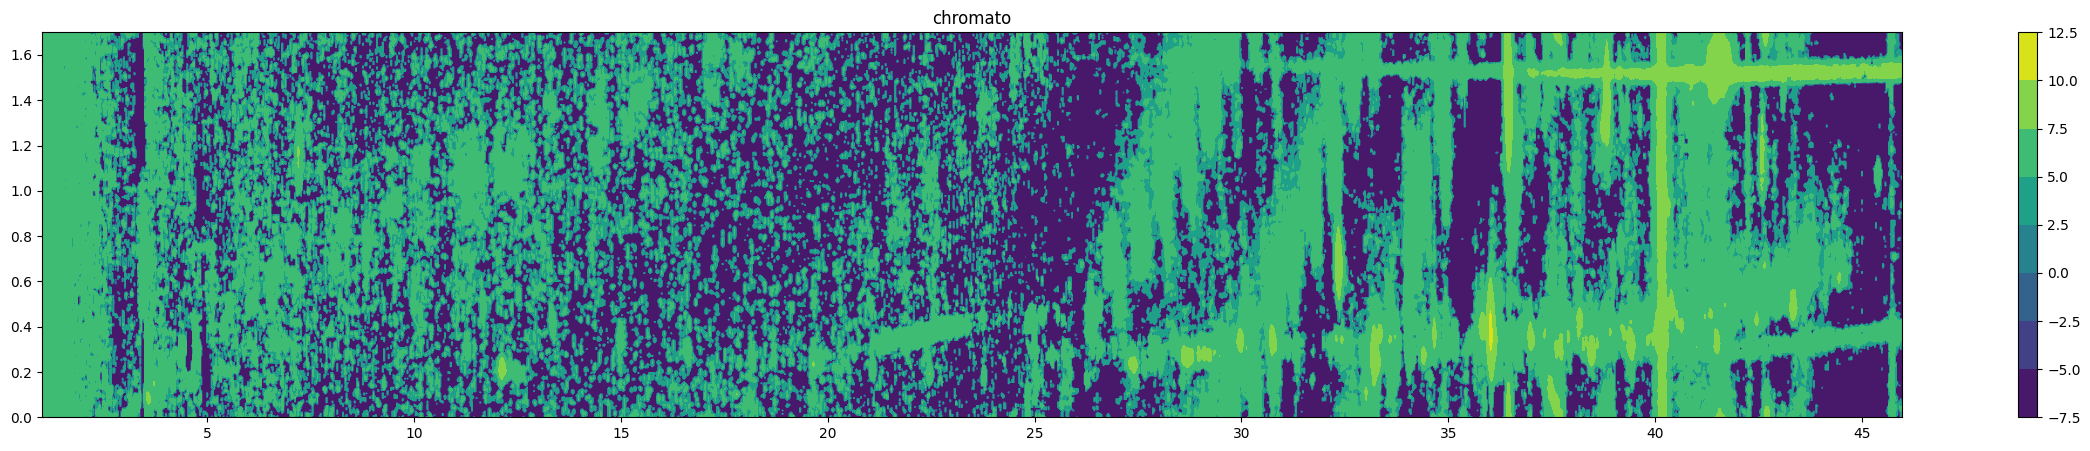

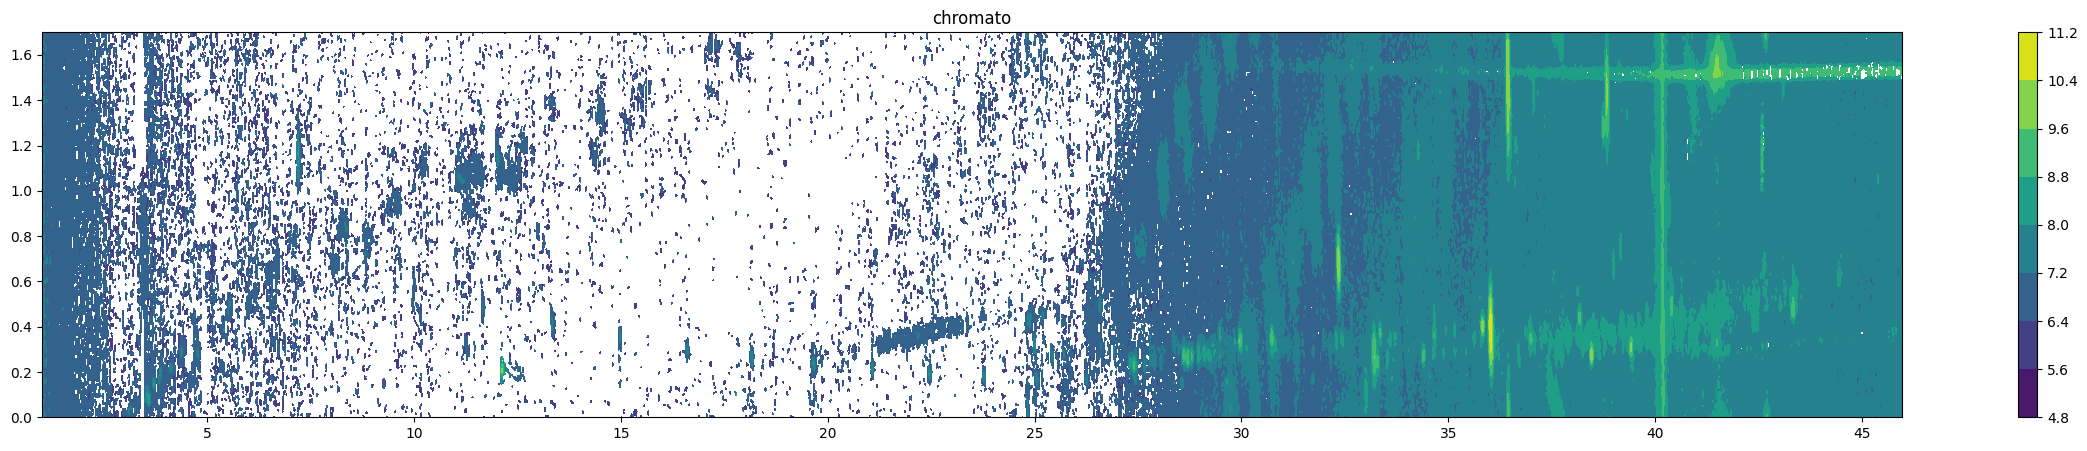

In [6]:
plt.rcParams['figure.figsize'] = [30, 5]
plot.visualizer2((baseline_cube[134,:,:], time_rn), title="chromato", log_chromato=True,  mod_time=1.7)
plot.visualizer2((chromato_cube[134,:,:], time_rn), title="chromato", log_chromato=True,  mod_time=1.7)

In [7]:
print("start peak detection")
results= dbscan_peak.detect_peak_dog_mp(baseline_cube,1000,
                       0.001,
                       5,
                       1, 3,
                       1.1,
                       0.5,multi_processing=True)

start peak detection


In [53]:

def cluster_per_mass(coordinate,radius,baseline_cube,chromato_cube,time_rn, mod_time,rt1_delta, rt2_delta,thr_debscan,max_peak_per_mass):
    coordinate_cluster=[]
    radius_cluster=[]
    for i in range(len(coordinate)):
        coordinate_cluster.append([])
        radius_cluster.append([])
    for mass in range(len(coordinate)) :
        coord_m=coordinate[mass]
        rad_m= radius[mass]
        tmp=baseline_cube[mass,:,:]
        npeak=len(coord_m)
        if(npeak!=0):
            # peak clusturing
            distance_matrix=dbscan_peak.compute_distance_metric(coord_m,chromato_cube,mod_time,time_rn,rt1_delta,rt2_delta)
            coord_cluster, rad_cluster , clusters, clusters_label= dbscan_peak.cluster_peak(distance_matrix,tmp,coord_m,rad_m,thr_debscan, min_sample_db_scan=1)

            if npeak > max_peak_per_mass:
                intensities = np.array([tmp[coord[0], coord[1]] for coord in coord_cluster])
                top_indices = np.argsort(intensities)[-max_peak_per_mass:][::-1]  # descending order
                coord_cluster = coord_cluster[top_indices]
                rad_cluster=rad_cluster[top_indices]
            
            # merge peaks cut but the modulation
            coordinates_in_chromato=projection.matrix_to_chromato(coord_cluster, time_rn,mod_time, tmp.shape)
            # 1.Identifier les lignes à supprimer (bound = up_bound + low_bound)
            mask = (coordinates_in_chromato[:, 1] > (mod_time-0.05)) | (coordinates_in_chromato[:, 1] < 0.05)
            if(any(mask)):
                bound= coord_cluster[mask] 
                radius_bound= rad_cluster[mask]      
                        # 2.cluster without RT2 penalty 
                distance_matrix=dbscan_peak.compute_distance_metric(bound,chromato_cube,mod_time,time_rn,rt1_delta=mod_time, rt2_delta=100000)
                bound_cluster, radius_bound_cluster, clusters, clusters_label = dbscan_peak.cluster_peak(distance_matrix,tmp,bound,radius_bound,thr_debscan=thr_debscan,min_sample_db_scan=1)
                        # 3. replace cluster 
                
                coord_cluster = np.concatenate((coord_cluster[~mask], bound_cluster), axis=0)
                rad_cluster = np.concatenate((rad_cluster[~mask], radius_bound_cluster), axis=0)
        else :
            coord_cluster = []
            rad_cluster = []
        coordinate_cluster[mass] = coord_cluster
        radius_cluster[mass]=rad_cluster
    return coordinate_cluster, radius_cluster

In [9]:
print("cluster per mass")
coordinate = [x[0] for x in results]
radius=[x[1] for x in results]
coordinate_cluster, radius=dbscan_peak.cluster_per_mass(coordinate,radius,baseline_cube,chromato_cube,time_rn,1.7,rt1_delta=10, rt2_delta=0.1,thr_debscan=0.03,max_peak_per_mass=400)    

cluster per mass


In [10]:
print(str(np.sum([len(x) for x in coordinate_cluster]))+ " peaks")

15249 peaks


In [ ]:
def fit_all_peaks_fixed_centers(tmp, coords, bounds, plot=False):
    ny, nx = tmp.shape
    fitted_results = []

    # --- Fenêtre de travail (comme avant) ---
    min_x = bounds[1][0]
    max_x = bounds[1][1]
    min_y = max(bounds[0][0], 0)
    max_y = min(ny, bounds[0][1])

    if (min_x < 0) and min_y >1:
        sub_tmp = np.hstack([tmp[(min_y-1):(max_y-1), (nx+min_x):nx], tmp[min_y:max_y, 0:max_x]])
    elif (max_x > nx) and max_y < (ny-1):
        sub_tmp = np.hstack([tmp[min_y:max_y, min_x:nx], tmp[(min_y+1):(max_y+1), 0:(max_x-nx)]])
    else:
        sub_tmp = tmp[min_y:max_y, min_x:max_x]

    H, W = sub_tmp.shape

    # --- Grille LOCALE (0..W-1, 0..H-1) -> centres et (x,y) dans le même repère ---
    xx_loc, yy_loc = np.meshgrid(np.arange(W), np.arange(H))

    # --- lmfit setup ---
    global fixed_centers
    fixed_centers = []
    params = Parameters()

    for i, (yy0_g, xx0_g) in enumerate(coords):
        # map global -> local
        # x : modulo pour tolérer un éventuel "wrap" horizontal ; y : clamp dans la fenêtre
        xx0 = (xx0_g - min_x) % W
        yy0 = int(np.clip(yy0_g - min_y, 0, H-1))

        amp0 = float(sub_tmp[yy0, xx0])

        # Estimation des sigmas dans la SOUS-FENÊTRE (indépendant de tmp global)
        sx1, sx2, sy1, sy2 = estimate_sigma_from_FWHM_asym(sub_tmp, (yy0, xx0))

        # Bornes un peu plus larges pour stabiliser le fit (évite un plafonnement trop tôt)
        local_max = float(sub_tmp.max())
        params.add(f'amp_{i}', value=amp0, min=0.0, max=max(amp0*3.0, local_max*1.2) + 1e-6)
        params.add(f'sx1_{i}',  value=sx1, min=0, max=max(sx1*2, 1e-6))
        params.add(f'sx2_{i}',  value=sx2, min=0, max=max(sx2*2, 1e-6))
        params.add(f'sy1_{i}',  value=sy1, min=0, max=max(sy1*2, 1e-6))
        params.add(f'sy2_{i}',  value=sy2, min=0, max=max(sy2*2, 1e-6))

        fixed_centers.append((yy0, xx0))  # centres en repère local

    # --- Fit sur la SOUS-FENÊTRE en repère local ---
    model = Model(multi_gaussian_lmfit, independent_vars=['x', 'y'])
    result = model.fit(
        sub_tmp.ravel(),
        x=xx_loc,
        y=yy_loc,
        params=params,
        method='leastsq',
        max_nfev=500  # un peu plus d'itérations
    )

    # --- Reconstructions & métriques ---
    fitted_peak_list = []
    for i, (yy0, xx0) in enumerate(fixed_centers):
        amp = result.params[f'amp_{i}'].value
        sx1 = result.params[f'sx1_{i}'].value
        sx2 = result.params[f'sx2_{i}'].value
        sy1 = result.params[f'sy1_{i}'].value
        sy2 = result.params[f'sy2_{i}'].value

        peak = twoD_Gaussian_bi_asym_fixed_center(
            (xx_loc, yy_loc), amp, sx1, sx2, sy1, sy2, xx0, yy0
        ).reshape(sub_tmp.shape)
        fitted_peak_list.append(peak)

        # renvoi des centres en coordonnées globales (utile pour la suite du pipeline)
        yy_g = yy0 + min_y
        xx_g = (xx0 + min_x) % nx

        fitted_results.append({
            "group_id": i,
            "center": (yy_g, xx_g),
            "params": (amp, sx1, sx2, sy1, sy2),
            "area": float(np.sum(peak))
        })

    fitted_data = np.sum(fitted_peak_list, axis=0) if fitted_peak_list else np.zeros_like(sub_tmp)

    y_true = sub_tmp.ravel().astype(float)
    y_pred = fitted_data.ravel().astype(float)
    sst = np.sum((y_true - y_true.mean())**2)
    ssr = np.sum((y_true - y_pred)**2)
    r2_total = 1.0 - ssr / sst if sst > 0 else float('nan')

    for rec in fitted_results:
        rec["r2_total"] = float(r2_total)

    if plot:
        vmin, vmax = np.min(sub_tmp), np.max(sub_tmp)
        fig, axes = plt.subplots(1, 2 + len(fitted_peak_list), figsize=(3 * (2 + len(fitted_peak_list)), 4))

        axes[0].contourf(sub_tmp.T, vmin=vmin, vmax=vmax)
        for (cy, cx) in fixed_centers:
            axes[0].plot(cy, cx, "ro", markersize=5)
        axes[0].set_title("Original (fenêtre locale)")

        axes[1].contourf(fitted_data.T, vmin=vmin, vmax=vmax)
        axes[1].set_title(f"Fit total (R² = {r2_total:.4f})")

        for k, peak in enumerate(fitted_peak_list):
            axes[2 + k].contourf(peak.T, vmin=vmin, vmax=vmax)
            axes[2 + k].set_title(f"Pic {k + 1}")

        plt.tight_layout()
        plt.show()

    return fitted_results

In [12]:
print("deconvolution per mass")
#quanti=deconvolution.deconvolution(baseline_cube, time_rn, 1.7, coordinate_cluster, radius,multi_processing=True)
quanti=[]
for m in range(baseline_cube.shape[0]):
    print(m)
    quanti.append(deconvolution.deconvolution_per_mass(coordinate_cluster[m], radius[m], baseline_cube[m,:,:],time_rn,1.7,plot_deconvo=False))

deconvolution per mass
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 9 and the array at index 1 has size 8

In [19]:
#quanti = [res for res in quanti if res is not None]
quanti_all_mass=[]
for m,elt in enumerate(quanti):
    if(len(elt[0])>0):
        for x,y in elt:
            quanti_all_mass.append([m,x,y])
coordinates_all_mass=[]
for elt in coordinate_cluster:
    for x,y in elt:
        coordinates_all_mass.append([x,y])
len(coordinates_all_mass)

29802

In [ ]:
print("compute distance metric "+ str(len(coordinates_all_mass)) + " peaks")
distance_matrix=dbscan_peak.compute_distance_metric(np.array(coordinates_all_mass),chromato_cube,1.7,time_rn,rt1_delta=1, rt2_delta=0.02)
coordinates, coordinates, clusters, label= dbscan_peak.cluster_peak(distance_matrix,chromato,coordinates_all_mass,coordinates_all_mass,thr_debscan=0.03,min_sample_db_scan=3)
print(len(coordinates))

compute distance metric 29802 peaks
1384


In [180]:
clusters[6] 

[[134, 197],
 [134, 197],
 [134, 198],
 [134, 197],
 [134, 196],
 [134, 196],
 [134, 202],
 [134, 195],
 [134, 196],
 [134, 197],
 [134, 194],
 [134, 197],
 [134, 199],
 [134, 198],
 [134, 198],
 [134, 197],
 [134, 197]]

In [181]:
sepc_list, area = deconvolution.construct_spectrum(quanti_all_mass,label,chromato_cube.shape[0])

In [199]:
len(sepc_list)

1384

In [193]:
import pandas as pd
import logging
import pyms
import pyms_nist_search

def matching_from_spectra(spectra):
    search = pyms_nist_search.Engine(
        "C:/Users/camil/Documents/NIST/mainlib/",
        pyms_nist_search.NISTMS_MAIN_LIB,
        "C:/Users/camil/Documents/NIST/mainlib/",
        )

    logger=logging.getLogger('pyms_nist_search')
    logger.setLevel('ERROR')
    logger=logging.getLogger('pyms')
    logger.setLevel('ERROR')
    masses=  np.arange(35, len(spectra)+35)

    mass_spectrum = pyms.Spectrum.MassSpectrum(masses, spectra)
    hits = search.full_search_with_ref_data(mass_spectrum, n_hits=5)
    return hits

import warnings
warnings.filterwarnings("ignore")
test=[]
for item in (sepc_list):
    test.append(matching_from_spectra(item)[0][0].match_factor)

(array([ 1.,  1.,  1.,  1.,  2.,  5., 13., 12., 22., 23., 28., 27., 38.,
        32., 44., 46., 45., 39., 54., 43., 35., 63., 40., 49., 45., 53.,
        44., 51., 47., 46., 30., 45., 39., 51., 30., 25., 26., 18., 27.,
        18., 22., 17., 20., 16., 18., 11.,  8.,  7.,  5.,  1.]),
 array([237.  , 251.88, 266.76, 281.64, 296.52, 311.4 , 326.28, 341.16,
        356.04, 370.92, 385.8 , 400.68, 415.56, 430.44, 445.32, 460.2 ,
        475.08, 489.96, 504.84, 519.72, 534.6 , 549.48, 564.36, 579.24,
        594.12, 609.  , 623.88, 638.76, 653.64, 668.52, 683.4 , 698.28,
        713.16, 728.04, 742.92, 757.8 , 772.68, 787.56, 802.44, 817.32,
        832.2 , 847.08, 861.96, 876.84, 891.72, 906.6 , 921.48, 936.36,
        951.24, 966.12, 981.  ]),
 <BarContainer object of 50 artists>)

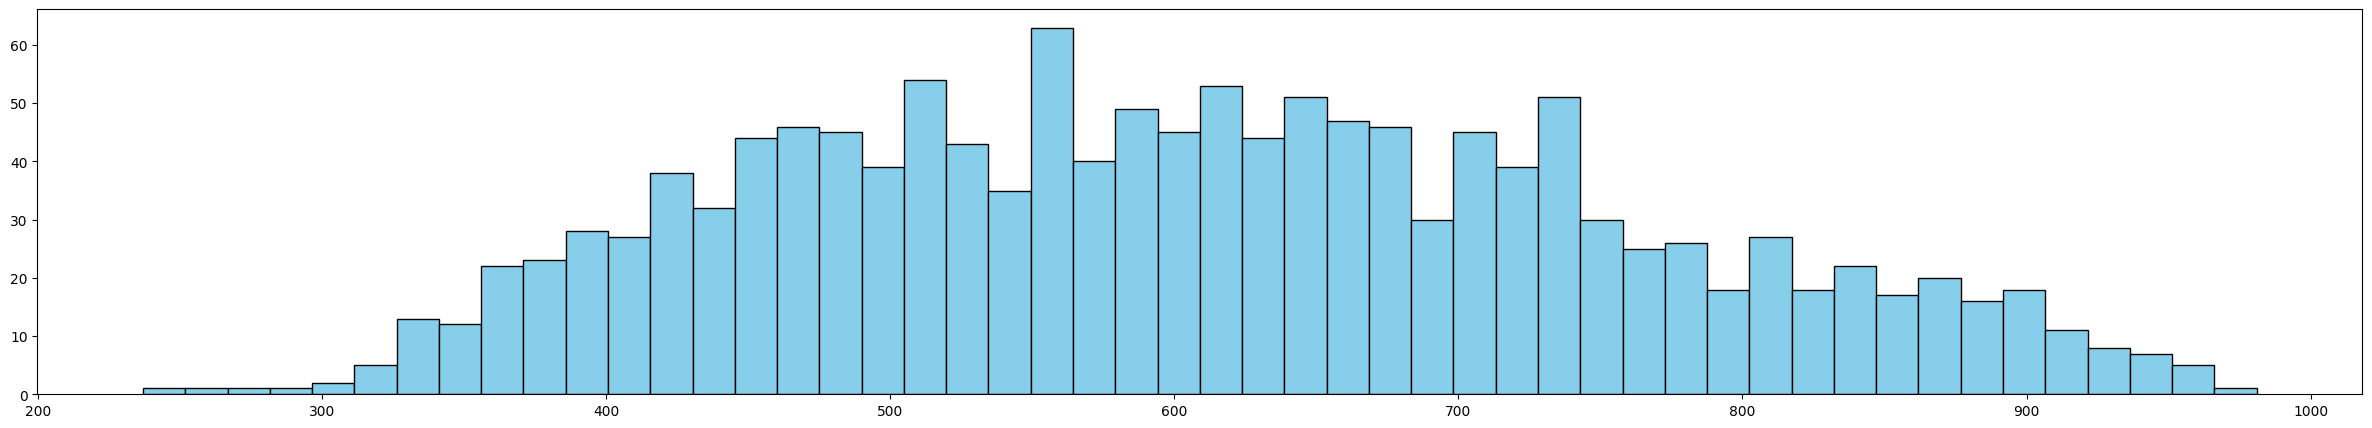

In [194]:
plt.rcParams['figure.figsize'] = [30, 5]

plt.hist(test, bins=50, color='skyblue', edgecolor='black')

605.0
645.0


(array([ 1.,  1.,  0.,  1.,  1.,  3.,  5.,  3., 11.,  8.,  8., 16.,  9.,
        15., 19., 21., 20., 24., 13., 22., 23., 22., 21., 25., 30., 24.,
        23., 33., 27., 24., 18., 24., 23., 32., 17., 21., 19.,  9., 12.,
        11., 18., 15.,  9., 18., 16., 15.,  7.,  6.,  7.,  5.]),
 array([261. , 275.1, 289.2, 303.3, 317.4, 331.5, 345.6, 359.7, 373.8,
        387.9, 402. , 416.1, 430.2, 444.3, 458.4, 472.5, 486.6, 500.7,
        514.8, 528.9, 543. , 557.1, 571.2, 585.3, 599.4, 613.5, 627.6,
        641.7, 655.8, 669.9, 684. , 698.1, 712.2, 726.3, 740.4, 754.5,
        768.6, 782.7, 796.8, 810.9, 825. , 839.1, 853.2, 867.3, 881.4,
        895.5, 909.6, 923.7, 937.8, 951.9, 966. ]),
 <BarContainer object of 50 artists>)

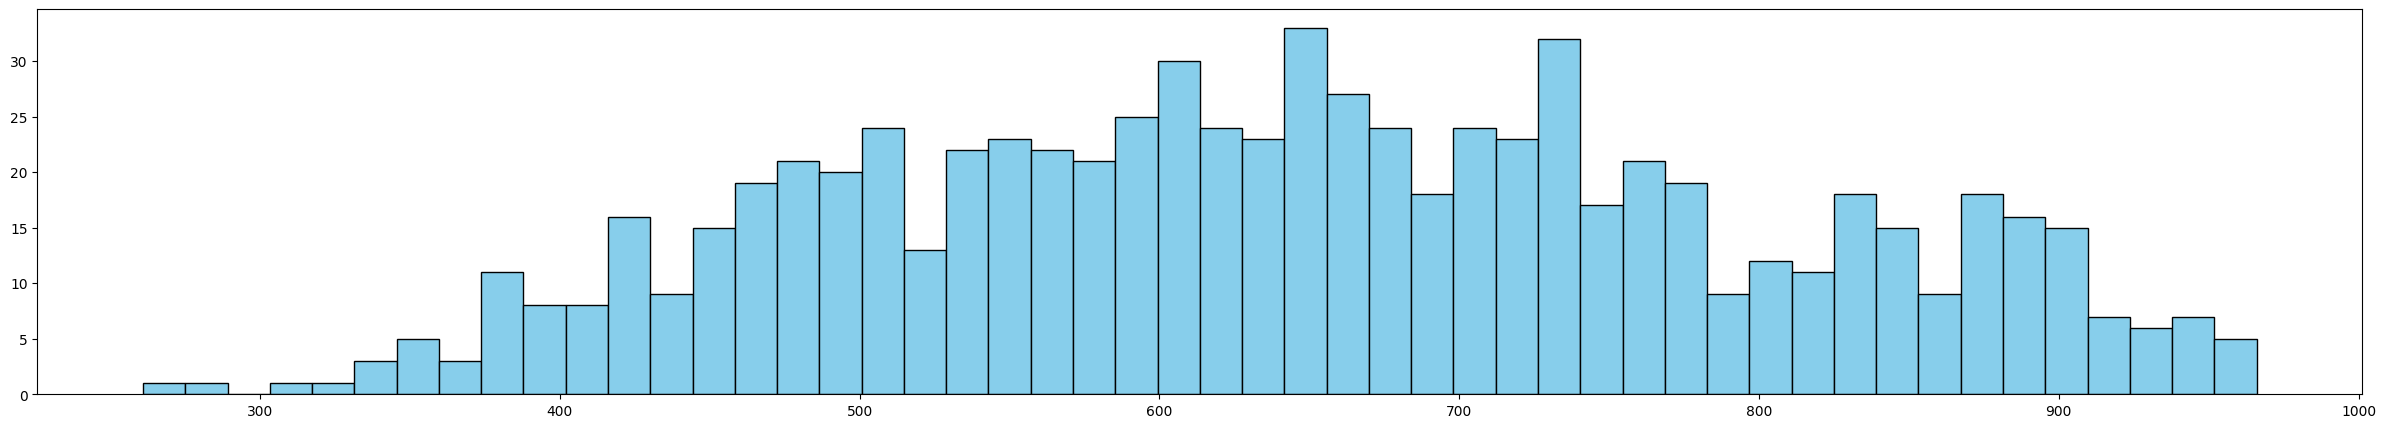

In [281]:
print(np.median(test))

print(np.median([x for j,x in enumerate(test) if coordinates_in_chromato[j][0]<30 ]))
plt.hist([x for j,x in enumerate(test) if coordinates_in_chromato[j][0]<30 ], bins=50, color='skyblue', edgecolor='black')

In [205]:
len(np.where(np.array(test)>650)[0])

542

In [331]:
matching_from_spectra(sepc_list[28])


[(Search Result: 2-Norbornen-5-ol, formate 	(489),
  Reference Data: 2-Norbornen-5-ol, formate 	(0-0-0)),
 (Search Result: 5-exo-norbornenol 	(459),
  Reference Data: 5-exo-norbornenol 	(2890-98-4)),
 (Search Result: 2-Norbornene 	(452),
  Reference Data: 2-Norbornene 	(498-66-8)),
 (Search Result: 1H-Pyrrole-2-carboxaldehyde 	(415),
  Reference Data: 1H-Pyrrole-2-carboxaldehyde 	(1003-29-8)),
 (Search Result: 2-Oxabicyclo[4.3.0]non-8-en-3-one, 4-methyl-, endo 	(410),
  Reference Data: 2-Oxabicyclo[4.3.0]non-8-en-3-one, 4-methyl-, endo 	(0-0-0))]

In [334]:
import plotly.graph_objects as go
import numpy as np
import kaleido


x_values = np.arange(len(sepc_list[0]))

# Create the bar plot for the first spectrum

bar_trace = go.Bar(x=x_values+35, y=sepc_list[28], name='Original Spectrum')
fig = go.Figure(data=[bar_trace])

fig


In [332]:
coordinates_in_chromato[28]

array([22.16500006,  1.695     ])

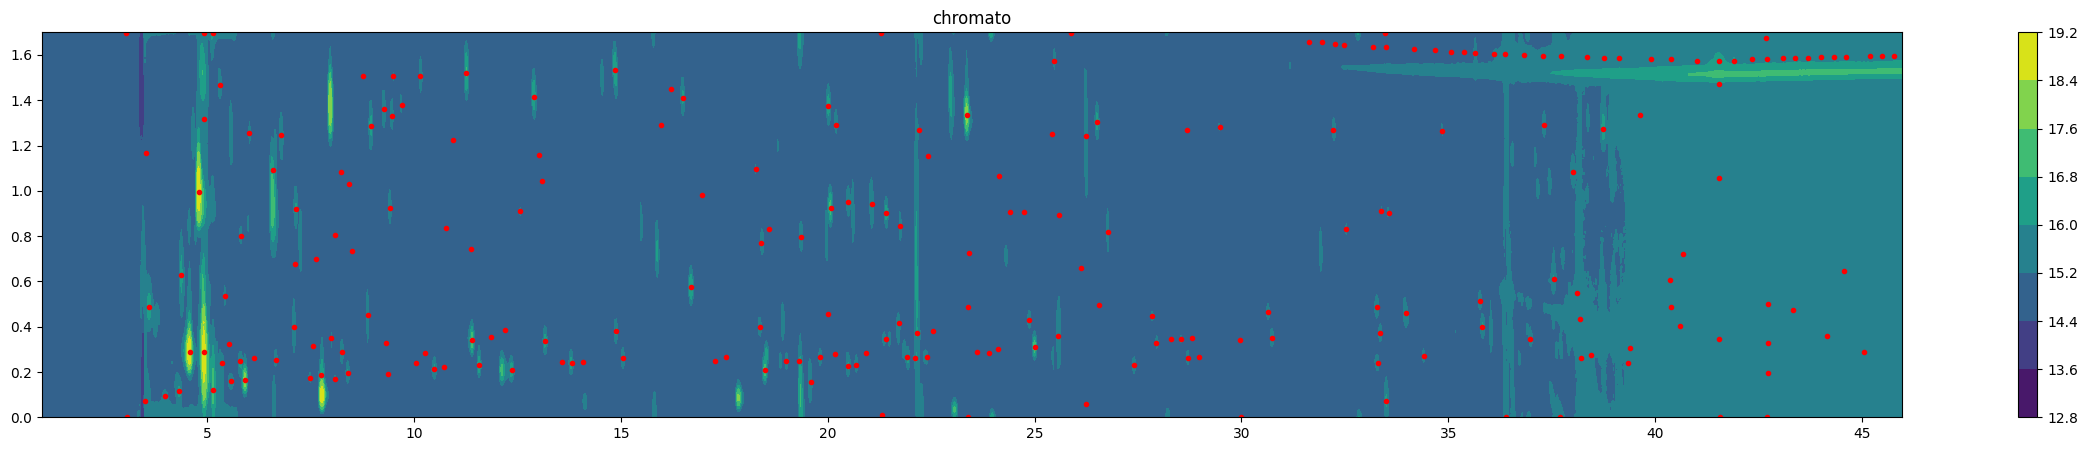

In [358]:
plt.rcParams['figure.figsize'] = [30, 5]
coordinates_in_chromato=projection.matrix_to_chromato(coordinates, time_rn, 1.7, chromato.shape)
plot.visualizer2((chromato, time_rn), title="chromato", log_chromato=True,  mod_time=1.7,points=coordinates_in_chromato)

In [142]:
[j for j,x in enumerate(coordinates_in_chromato) if 7.8<x[0]<8.1 and 1.3<x[1]<1.5]

[7]

In [68]:
np.where(np.array([len(x) for x in res])>1)

(array([32, 56, 61, 65, 67], dtype=int64),)

In [71]:
np.sum([len(x) for x in clusters])

131

In [37]:
len(coordinate_cluster[m])

0

In [ ]:
m=400
res=deconvolution.deconvolution_per_mass(coordinate_cluster[m], radius[m], baseline_cube[m,:,:],time_rn,1.7,plot_deconvo=True)

In [14]:
import skimage
import math
def detect_peak_dog( chromato_tic,
                    abs_threshold,
                    rel_threshold,
                    noise_factor,
                    min_sigma, max_sigma,
                    sigma_ratio,
                    overlap):
        
        sigma = estimate_sigma(chromato_tic, channel_axis=None)
        intensity_threshold = dbscan_peak.intensity_threshold_decision_rule(
            abs_threshold, rel_threshold, noise_factor, sigma, chromato_tic)
        blobs_dog = skimage.feature.blob_dog(chromato_tic, min_sigma=min_sigma,
                                             max_sigma=max_sigma, 
                                             overlap=overlap,
                                             threshold=intensity_threshold,
                                             sigma_ratio=sigma_ratio)
        # Compute radii in the 3rd column.
        #blobs_dog[:, 2] = blobs_dog[:, 2] * math.sqrt(2)
        
        #blobs_dog = np.array(blobs_dog)
        #coordinates, radius = np.delete(blobs_dog, 2, -1), blobs_dog[:, 2]
        
        # blobs_dog shape: (N, 3), where columns are (y, x, sigma)
        # Adjust radii: radius = sigma * sqrt(2)
        radii = blobs_dog[:, 2] 

        # Keep coordinates as float (y,x)
        blobs_dog = np.rint(blobs_dog).astype(int)
        coordinates = np.array(blobs_dog[:, :2])
        
        return coordinates , radii


In [451]:
m

224

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# ouverture du pdf
with PdfPages("D:/chromato_results4.pdf") as pdf:

    for m in range(chromato.shape[0])[224:]:  
        print(f"Processing m={m}")

        correct= baseline_correct(chromato_cube[m,:,:],block_size=20,gamma=0.25, lmbd=15)
        correct= smooth2d(correct, lmbd=1, lmbd2=1)
        
        coordinate_before, radius = detect_peak_dog(
            correct, abs_threshold=500, rel_threshold=0.001,
            noise_factor=5, min_sigma=1, max_sigma=3,
            sigma_ratio=1.1, overlap=0.5
        )

        # ========== Peak clustering ==========
        if(len(coordinate_before)>0):
            distance_matrix = dbscan_peak.compute_distance_metric(coordinate_before, chromato_cube, 1.7, time_rn, 5, 0.1)
            clustering = DBSCAN(eps=0.03, min_samples=1, metric='precomputed').fit(distance_matrix)
            labels = clustering.labels_
            unique_labels = set(labels)
            unique_labels.discard(-1)
            ncluster = len(unique_labels)

            clusters = [[] for _ in range(ncluster)]
            for i in range(len(coordinate_before)):
                clusters[clustering.labels_[i]].append(([coordinate_before[i], radius[i]]))

            coordinates, radius_new = [], []
            for cluster in clusters:
                if len(cluster) > 1:
                    idx = np.argmax(np.array([chromato[coord[0][0], coord[0][1]] for coord in cluster]))
                    coord = cluster[idx][0]
                    rad = cluster[idx][1]
                else:
                    coord = cluster[0][0]
                    rad = cluster[0][1]
                coordinates.append(coord)
                radius_new.append(rad)
            coordinates = np.array(coordinates)

            # ========== Création des deux plots sur la même figure ==========
            fig, axes = plt.subplots(2, 1, figsize=(30, 10))

            # --- Plot 1 : contour avec points
            contour = axes[0].contourf(np.log(correct.T))
            plt.colorbar(contour, ax=axes[0])
            axes[0].set_title(f"m={m} - Contour")
            axes[0].plot(coordinate_before[:,0], coordinate_before[:,1], "b.")
            axes[0].plot(coordinates[:,0], coordinates[:,1], "r.")

            # --- Plot 2 : visualisation cluster
            chromato_safe = np.where(
                chromato_cube[m,:,:] <= 0,
                np.min(chromato_cube[m,:,:][chromato_cube[m,:,:] > 0]),
                chromato_cube[m,:,:]
            )
            contour = axes[1].contourf(np.log(chromato_safe.T))
            plt.colorbar(contour, ax=axes[1])
            axes[1].set_title(f"Clusters: {len(coordinate_before)-len(coordinates)} merged, {len(coordinates)} kept")
            axes[1].plot(coordinates[:,0], coordinates[:,1], "r.")

            # enregistrer la page dans le pdf
            pdf.savefig(fig)
            plt.close(fig)

print("✅ PDF généré : chromato_results.pdf")


In [740]:
label = [x for j, x in enumerate(clusters_label) if not mask[j]] + label_bis
len(label)

75

In [741]:
label[74]

[9]

In [ ]:
coordinate_before[9]

array([1538,  305])

In [93]:
# Taille du carré
import numpy as np
from scipy.interpolate import griddata
import numpy as np
from scipy.interpolate import griddata
from whittaker_eilers import WhittakerSmoother
from scipy.ndimage import map_coordinates
def smooth2d(arr, lmbd=25,lmbd2=25):
    # Lissage par lignes
    smoother = WhittakerSmoother(lmbda=lmbd2, order=1, data_length=arr.shape[1])
    arr_smooth = np.array([smoother.smooth(row) for row in arr])

    # Lissage par colonnes
    smoother = WhittakerSmoother(lmbda=lmbd, order=1, data_length=arr.shape[0])
    arr_smooth = np.array([smoother.smooth(col) for col in arr_smooth.T]).T
    
    return arr_smooth

def baseline_correct(mat,block_size = 20,gamma=0.25,lmbd=15):
    
    # mat= savgol_filter(mat,
    #        window_length=100,  # 5, 11 pour un lissage + fort
    #        polyorder=3,
    #        mode='nearest')
    
    if(np.all(mat==0)) :
        return mat
    chrom=mat
    
    mat = smooth2d(mat, lmbd=15,lmbd2=15)
    n=mat.shape[0]
    m=mat.shape[1]
    n_blocks = (n + block_size - 1) // block_size
    m_blocks = (m + block_size - 1) // block_size

    min_grid = np.zeros((n_blocks, m_blocks))

    for bi, i in enumerate(range(0, n, block_size)):
        for bj, j in enumerate(range(0, m, block_size)):
            block = mat[i:i+block_size, j:j+block_size]
            min_grid[bi, bj] = block.min()

    min_grid_smooth = smooth2d(min_grid, lmbd=15)
    sigma=np.std(min_grid)

    # --- 3. Préparer pour interpolation ---
    points = []
    values = []
    for bi in range(n_blocks):
        for bj in range(m_blocks):
            ci = bi*block_size + block_size//2
            cj = bj*block_size + block_size//2
            if ci < n and cj < m:  # éviter dépassement
                points.append((ci, cj))
                values.append(min_grid_smooth[bi, bj])

    points = np.array(points)
    values = np.array(values) + gamma*sigma

    # Grille complète (n x m)
    grid_x, grid_y = np.mgrid[0:n, 0:m]

    # --- 4. Interpolation linéaire 2D ---
    interp_mat = map_coordinates(min_grid_smooth, [grid_x/block_size, grid_y/block_size], order=1, mode='nearest')

    #interp_mat = griddata(points, values, (grid_x, grid_y), method='nearest')

    correct=smooth2d(chrom, lmbd=lmbd, lmbd2=lmbd)
    correct=correct-interp_mat
    correct[correct<0]=min(correct[correct>0])
    
    return(correct)

65.8113883008419


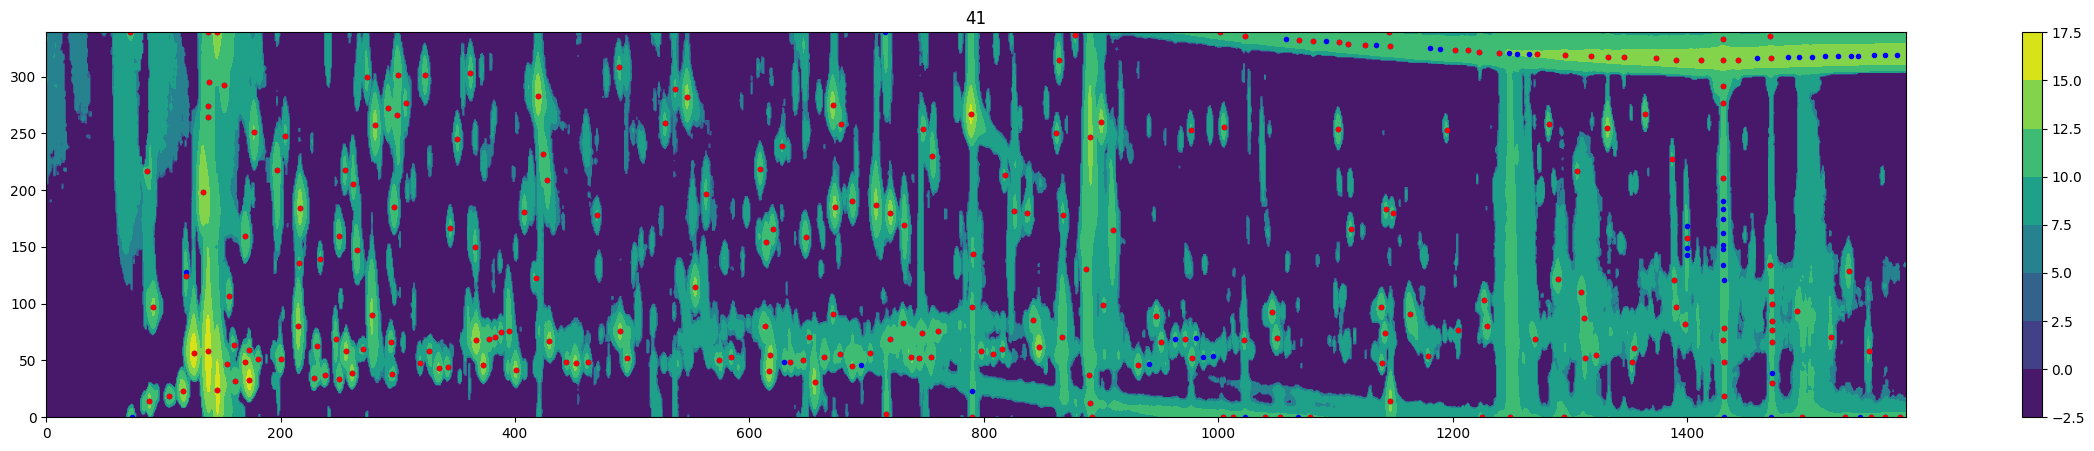

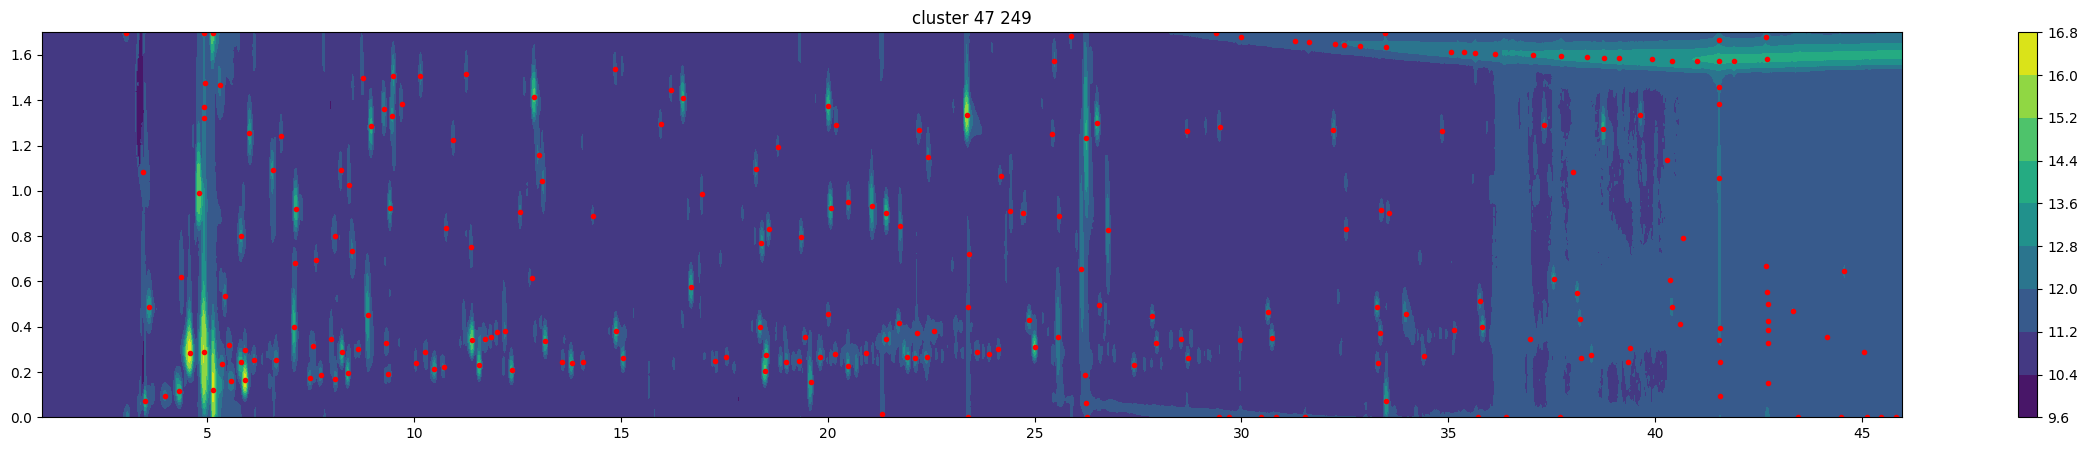

In [100]:
import baseline_correction
m= 41-35
chromato_tic=chromato_cube[m,:,:]
optimal_lambda_list=[]
        # find optimal lambda for smoothing 
for j in range(0,chromato_tic.shape[1],10):
        data_to_smooth = chromato_tic[:,j]
        smoother = WhittakerSmoother(lmbda=10, order=1, data_length=len(data_to_smooth))
        results = smoother.smooth_optimal(data_to_smooth, break_serial_correlation=True)
        optimal_lambda = results.get_optimal().get_lambda()
        optimal_lambda_list.append(optimal_lambda)
        
optimal_lambda=np.quantile(optimal_lambda_list,0.5)
print(optimal_lambda)
if optimal_lambda >10 :
        optimal_lambda=10
elif optimal_lambda <5:
        optimal_lambda=5

correct= baseline_correct(chromato_cube[m,:,:],block_size=20,gamma=0.25, lmbd=1)
#correct= baseline_cube[m,:,:]
coordinate_before, radius = detect_peak_dog(correct, abs_threshold=1000,
                        rel_threshold=0.001,
                        noise_factor=5,
                        min_sigma=1, max_sigma=3,
                        sigma_ratio=1.1,
                        overlap=0.5)

# peak clusturing
distance_matrix=dbscan_peak.compute_distance_metric(coordinate_before,baseline_cube,1.7,time_rn,10, 0.1)
coordinates, radius , clusters, clusters_label= dbscan_peak.cluster_peak(distance_matrix,correct,coordinate_before,radius,0.03,1)


# merge peaks cut but the modulation
coordinates_in_chromato=projection.matrix_to_chromato(coordinates, time_rn, 1.7, chromato.shape)
     # 1.Identifier les lignes à supprimer (bound = up_bound + low_bound)
mask = (coordinates_in_chromato[:, 1] > (1.7-0.05)) | (coordinates_in_chromato[:, 1] < 0.05)
bound= coordinates[mask] 
radius_bound= radius[mask]      
        # 2.cluster without RT2 penalty 
distance_matrix=dbscan_peak.compute_distance_metric(bound,chromato_cube,1.7,time_rn,rt1_delta=1.7, rt2_delta=100000)
bound_cluster, radius_bound_cluster, clusters_bis, label_bis=dbscan_peak.cluster_peak(distance_matrix,correct,bound,radius_bound,thr_debscan=0.02,min_sample_db_scan=1)
        # 3. replace cluster 
coordinates = np.concatenate((coordinates[~mask], bound_cluster), axis=0)
radius = np.concatenate((radius[~mask], radius_bound_cluster), axis=0)
clusters = [x for j, x in enumerate(clusters) if not mask[j]] + clusters_bis
clusters_label = [x for j, x in enumerate(clusters_label) if not mask[j]] + label_bis


plt.rcParams['figure.figsize'] = [30, 5]
coordinates_in_chromato=projection.matrix_to_chromato((coordinates), time_rn, 1.7, chromato.shape)
fig, ax = plt.subplots()
contour =ax.contourf(np.log(correct.T))
plt.colorbar(contour, ax=ax)  # associer explicitement la colorbar à l'axe
plt.title(str(m+35))
ax.plot(coordinate_before[:,0], coordinate_before[:,1], "b.")
ax.plot(coordinates[:,0], coordinates[:,1], "r.")
chromato_safe = np.where(chromato_cube[m,:,:] <= 0, min(chromato_cube[m,:,:][chromato_cube[m,:,:]>0]), chromato_cube[m,:,:])
plot.visualizer2((chromato_safe,time_rn), title="cluster " + str(len(coordinate_before)-len(coordinates)) + " " + str(len(coordinates)) , log_chromato=True,  mod_time=1.7, rt1_window=0.1, rt2_window=0.2,points=coordinates_in_chromato)


In [ ]:
mat = smooth2d(mat, lmbd=lmbd,lmbd2=lmbd)


In [43]:
coordinates_in_chromato=projection.matrix_to_chromato((coordinates), time_rn, 1.7, chromato.shape)
bounds = deconvolution.compute_bounds(coordinates_in_chromato, radius)
clusters = deconvolution.cluster_bounds(coordinates_in_chromato,bounds,time_rn, 1.7,   chromato.shape)
final_bounds = deconvolution.expand_cluster_bounds(bounds, clusters)
print(len(clusters))
max([len(x) for x in clusters]) # mettre max 4 pics 

169


2

In [44]:
res=[]
for j in range(len(clusters)):
   res.append(deconvolution.fit_all_peaks_fixed_centers(correct, coordinates[clusters[j]], projection.chromato_to_matrix(final_bounds[j].T,time_rn, 1.7, chromato.shape).T, plot=False))

In [ ]:
plt.rcParams['figure.figsize'] = [5, 5]

coordinates__first=projection.matrix_to_chromato((coordinates), time_rn, 1.7, chromato.shape)
for i in range(0,len(radius),15):
    plot.visualizer2((chromato_safe,time_rn), title=i , log_chromato=True,  mod_time=1.7, 
                 rt1=coordinates__first[i][0], rt2=coordinates__first[i][1],points=coordinates__first, rt1_window= radius[i] * 3 * 1.7/60,rt2_window=radius[i] * 5* 0.005)


In [249]:
from sklearn.cluster import DBSCAN
from scipy.spatial.distance import cdist
import numpy as np

coordm = coordinates

# --- Étape 1 : former les groupes par recouvrement de fenêtre ---
rt_vals = projection.matrix_to_chromato(coordm, time_rn, 1.7, chromato.shape)
rt_vals[:, 0] = rt_vals[:, 0] * 60
scaled_rt = rt_vals / np.array([10, 0.15])

# matrice de distances (L1 / Manhattan)
penalty_matrix = 0.01 * cdist(scaled_rt, scaled_rt, metric='cityblock')

clustering = DBSCAN(eps=0.01, min_samples=1, metric='precomputed').fit(penalty_matrix)
labels = clustering.labels_

clusters = []
for i in range(max(labels) + 1):
    clusters.append(np.where(labels == i)[0].tolist())

# --- Étape 2 : subdivision des clusters > 7 ---
final_clusters = []

for cluster in clusters:
    if len(cluster) <= 7:
        final_clusters.append(cluster)
    else:
        # extraire les points du cluster
        sub_coords = scaled_rt[cluster]

        # recalculer matrice de distances pour ce sous-cluster
        sub_penalty_matrix = 0.01 * cdist(sub_coords, sub_coords, metric='cityblock')

        # relancer DBSCAN plus strict
        sub_clustering = DBSCAN(eps=0.005, min_samples=1, metric='precomputed').fit(sub_penalty_matrix)
        sub_labels = sub_clustering.labels_

        for sub_label in set(sub_labels):
            sub_idx = np.where(sub_labels == sub_label)[0]
            sub_cluster = [cluster[i] for i in sub_idx]

            # si encore trop gros (>7), tu pourrais relancer récursivement ici
            if len(sub_cluster) > 7:
                # récursion : appeler la même logique
                # (ici je le fais inline pour simplicité)
                sub_sub_coords = scaled_rt[sub_cluster]
                sub_sub_penalty_matrix = 0.01 * cdist(sub_sub_coords, sub_sub_coords, metric='cityblock')
                sub_sub_clustering = DBSCAN(eps=0.005, min_samples=1, metric='precomputed').fit(sub_sub_penalty_matrix)
                sub_sub_labels = sub_sub_clustering.labels_
                for sub_sub_label in set(sub_sub_labels):
                    idx = np.where(sub_sub_labels == sub_sub_label)[0]
                    final_clusters.append([sub_cluster[j] for j in idx])
            else:
                final_clusters.append(sub_cluster)

# Résultat final
clusters = final_clusters


In [ ]:
[j for j, x in enumerate(clusters) if len(x)>1]

In [ ]:
i=30

from matplotlib.backends.backend_pdf import PdfPages

pdf = PdfPages('D:/baseline_test.pdf')  # Open PDF explicitly


for i in range(chromato_cube.shape[0]):
    data_to_smooth = np.sum(chromato_cube[i,:,:],axis=1)
    smoother = WhittakerSmoother(lmbda=1, order=1, data_length=len(data_to_smooth))
    results = smoother.smooth_optimal(data_to_smooth, break_serial_correlation=True)
    optimally_smoothed_series = results.get_optimal().get_smoothed()
    optimal_lambda = results.get_optimal().get_lambda()
    print(optimal_lambda)
    if optimal_lambda >50 :
        optimal_lambda=50
    elif optimal_lambda <10:
        optimal_lambda=50
    correct=baseline_correct(chromato_cube[i,:,:],block_size=20, lmbd=optimal_lambda)
    coord, radius = dbscan_peak.detect_peak_dog(correct, abs_threshold=0,
                        rel_threshold=0.001,
                        noise_factor=5,
                        min_sigma=1, max_sigma=8,
                        sigma_ratio=1.1,
                        overlap=0.95)
    distance_matrix=dbscan_peak.compute_distance_metric(coord,chromato_cube,1.7,time_rn,5, 0.1)
    coordinates, clusters= dbscan_peak.cluster_peak(distance_matrix,correct,coord,0.05,min_sample_db_scan=1)
    coordinates_in_chromato=projection.matrix_to_chromato((coordinates), time_rn, 1.7, chromato.shape)
    fig, ax = plt.subplots()
    contour =ax.contourf(np.log(correct.T))
    plt.colorbar(contour, ax=ax)  # associer explicitement la colorbar à l'axe
    plt.title(str(i+35))
    ax.plot(coord[:,0], coord[:,1], "b.")
    ax.plot(coordinates[:,0], coordinates[:,1], "r.")
    pdf.savefig(fig)
    plt.close(fig)
    chromato_safe = np.where(chromato_cube[i,:,:] <= 0, 0.01, chromato_cube[i,:,:])
    fig=plot.visualizer2((chromato_safe,time_rn), title="cluster " + str(len(coord)-len(coordinates)) + " " , log_chromato=True,  mod_time=1.7, rt1_window=2, rt2_window=1,points=coordinates_in_chromato)
    pdf.savefig(fig)  # Save current figure to PDF
    plt.close(fig)    # Close figure to free memory
    print(str(i) + str(len(coord)-len(coordinates)))
pdf.close()  # Close the PDF file explicitly



In [673]:
pdf.close()

In [ ]:
## group pics for déconvolution 
rt_vals= projection.matrix_to_chromato(coordinates, time_rn,1.7,chromato.shape)
rt_vals[:,0]=rt_vals[:,0]*60
scaled_rt = rt_vals / np.array([6, 0.05])
        
    # Compute Manhattan (L1) distance between all rows
penalty_matrix =0.01* cdist(scaled_rt, scaled_rt, metric='cityblock')  # sum of |ΔRT1| + |ΔRT2|
clustering = DBSCAN(eps=0.01, min_samples=1, metric='precomputed').fit(penalty_matrix)
labels = clustering.labels_
unique_labels = set(labels)
unique_labels.discard(-1)  # Ignore noise
ncluster=len(unique_labels)
clusters = []
for i in range(ncluster):
    clusters.append([])
for i, (t1, t2) in enumerate(coordinates):
    clusters[clustering.labels_[i]].append(i)
groups=clusters

shape = chromato.shape
mod_time=1.7
X= np.arange(time_rn[0], time_rn[1], mod_time/60)[:-1]
Y = np.linspace(0, mod_time, shape[1])
chromato = np.transpose(chromato)
fig, ax = plt.subplots()
tmp = ax.contourf(X, Y, chromato)
colors = ['r', 'g', 'b', 'c', 'm', 'y']
for i in range(5):
    points = coordinates_in_chromato[groups[i]]
    ax.plot(points[:, 0], points[:, 1], '.', color=colors[i])
plt

In [ ]:
from dbscan_peak import intensity_threshold_decision_rule

thr=[]
for m in range(chromato_cube.shape[0]) :
    sigma = estimate_sigma(chromato_cube[m,:,:], channel_axis=None)
    intensity_threshold = intensity_threshold_decision_rule(
            500, 0.001, 5, sigma, chromato_cube[m,:,:])
    thr.append(intensity_threshold)

info_par_peak=[]
for item in matches:
    indices_masses=np.where((item[1][0]['spectra'])>thr)[0]
    majority_mass=np.argmax((item[1][0]['spectra']))
    info_par_peak.append((majority_mass, indices_masses))

# Initialiser la liste des masses avec des listes vides
masses_with_peak_indices = [[[],[]] for _ in range(chromato_cube.shape[0])]

# Remplir la structure : pour chaque pic, ajouter son index aux masses correspondantes
for peak_index, peak_info in enumerate(info_par_peak):
    for mass_index in peak_info[1]:
        masses_with_peak_indices[mass_index][1].append(peak_index)
    masses_with_peak_indices[peak_info[0]][0].append(peak_index) # arg max

In [ ]:
[j for j,c in enumerate(coordinates_in_chromato) if 10.22<c[0]<10.36 and 0.15<c[1]<0.45]


In [ ]:
coords= coordinates[[255, 802]]

list_res=[]
for j in list(set(info_par_peak[255][1]) | set(info_par_peak[802][1])) :
    res=fit_all_peaks_fixed_centers(chromato_cube[j,:,:],coords,window_1=3, window_2=20,plot=True)
    list_res.append(res)

In [ ]:
spec_esti = np.zeros(len(matches[328][1][0]['spectra']))  
for j, m in enumerate(list(set(info_par_peak[255][1]) | set(info_par_peak[802][1]))) :
    spec_esti[m]= list_res[j][1]['params'][0]

print(matching_from_spectra(spec_esti))
print(matching_from_spectra(matches[802][1][0]['spectra'] ))

import plotly.graph_objects as go
import numpy as np
import kaleido

# Example spectra data
# Replace these with your actual spectra arrays
spectrum2 = spec_esti  # First spectrum for bar plot
spectrum1 = matches[802][1][0]['spectra']  # Second spectrum for line plot

# Generate x-axis values
x_values = np.arange(len(spectrum1))

# Create the bar plot for the first spectrum
bar_trace = go.Bar(x=x_values, y=spectrum1, name='Original Spectrum')

# Create the line plot for the second spectrum
line_trace = go.Scatter(x=x_values, y=spectrum2, mode='lines', name='Estimated Spectrum', line=dict(color='red'))

# Combine both plots
fig = go.Figure(data=[bar_trace, line_trace])

fig


In [ ]:
coords= np.array([([1283,   85]),
 ([1278,   84]),
 ([1279,   73]),
 ([1280,   60])])

res=fit_all_peaks_fixed_centers(tmp,coords,plot=True)

In [ ]:
from matplotlib.backends.backend_pdf import PdfPages
pdf = PdfPages('D:/test_deconvo_plot2.pdf') 

mass_with_argmax = list(set([m[0]for m in info_par_peak ]))
for m in mass_with_argmax:
    peak_to_quanti = masses_with_peak_indices[m][0]
    all_peaks= masses_with_peak_indices[m][1]
    for i in peak_to_quanti:
        all_peaks.append(i)
        plt.rcParams['figure.figsize'] = [10, 5]
        fig=plot.visualizer2((chromato_cube[m,:,:],time_rn),mod_time=1.7,rt1=matches[i][0][0],rt2=matches[i][0][1],log_chromato=False,rt1_window=0.1,rt2_window=0.2, points=coordinates_in_chromato[all_peaks],
                            title=f"{m + mass_range[0]} / {i} /{ round(matches[i][0][0],4)}/ {round(matches[i][0][1],4)}", )        
        pdf.savefig(fig)  
        plt.close(fig)    

pdf.close()  

c

In [ ]:
ny, nx = tmp.shape
fitted_results = []
visited = set()
fitted_peak=[]
for i, (cy, cx) in enumerate(coords):
    if (cy, cx) in visited:
        continue

        # Cherche pics proches
    close_indices = [j for j, (yy, xx) in enumerate(coords)
                        if np.hypot(yy - cy, xx - cx) <= 50]
    for j in close_indices:
        visited.add(tuple(coords[j]))

        # Détermine zone globale pour fit
    min_x = max(0, int(min(cx - 40, *(coords[j][1] - 40 for j in close_indices))))
    max_x = min(nx, int(max(cx + 40, *(coords[j][1] + 40 for j in close_indices)))+1)
    min_y = max(0, int(min(cy -4, *(coords[j][0] - 4 for j in close_indices))))
    max_y = min(ny, int(max(cy + 4, *(coords[j][0] +4 for j in close_indices)))+1)

    sub_tmp = tmp[min_y:max_y, min_x:max_x]
    xx, yy = np.meshgrid(np.arange(min_x, max_x), np.arange(min_y, max_y))

        # Paramètres initiaux (sans centres)
    p0 = []
    fixed_centers = []
    for j in close_indices:
        yy0, xx0 = coords[j]
        amp = tmp[yy0, xx0]
        p0.extend([amp, 3, 3, 0, 0])  # no xo, yo here
        fixed_centers.append((yy0, xx0))

        # Fit
    popt, _ = curve_fit(
            lambda crd, *prm: multi_gaussian_fixed_centers(crd, *prm, centers=fixed_centers),
            (xx, yy),
            sub_tmp.ravel(),
            p0=p0
        )

        # Aire pour chaque gaussienne
    n_params = 5
    
    for k, (yy0, xx0) in enumerate(fixed_centers):
        amp, sx, sy, th, off = popt[k*n_params:(k+1)*n_params]
        fitted_peak .append(twoD_Gaussian_asym_fixed_center((xx, yy), amp, sx, sy, th, 0, xx0, yy0).reshape(sub_tmp.shape))
        area = np.sum(fitted_peak)
        fitted_results.append({
                "center": (yy0, xx0),
                "params": (amp, sx, sy, th, off),
                "area": area
            })
